In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [80]:
import kagglehub

path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mobile-price-classification' dataset.
Path to dataset files: /kaggle/input/mobile-price-classification


In [81]:
#test.csv
df = pd.read_csv("/kaggle/input/mobile-price-classification/train.csv")
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [82]:
df.head()
df.info()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [83]:
x = df.drop("price_range" , axis=1)
y = df["price_range"]




In [84]:
x_train, x_test, y_train, y_test = train_test_split(
x,y,test_size=0.2, random_state=42, stratify=y
)

In [85]:
param_grid = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [None, 10,20,30],
    'min_samples_split' : [2,5,10],
     'min_samples_leaf' : [1,2,5],
    'max_features' : ['sqrt', 'log2', None]
}



In [86]:
from numpy.random.mtrand import random
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
   param_grid= param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(x_train, y_train)

best_dt = grid.best_estimator_
print("Best Hyperparameters: ", grid.best_params_)
print("Best CV f1_macro :", grid.best_score_)


Best Hyperparameters:  {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV f1_macro : 0.8417680202188784


In [87]:
y_pred = best_dt.predict(x_test)
print("\nTest Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred ))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred)
)

# importances = best_dt.feature_importances_
# top_idx = np.argsort(importances)[-10:][::-1]

# print("\nTop 10 important terms:")
# for idx in top_idx:
#   print(f" {features[idx]:<15}" )



Test Accuracy : 0.8725

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       100
           1       0.84      0.81      0.83       100
           2       0.82      0.80      0.81       100
           3       0.90      0.93      0.92       100

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400

Confusion Matrix:
 [[95  5  0  0]
 [ 9 81 10  0]
 [ 0 10 80 10]
 [ 0  0  7 93]]


In [88]:
importances = best_dt.feature_importances_

feature_imp = pd.DataFrame({
    'Feature' : x.columns,
    'Importance' : importances
})

print(
    feature_imp.sort_values(
        by='Importance',
        ascending=False
    )
)

          Feature  Importance
13            ram    0.702138
0   battery_power    0.111115
12       px_width    0.095891
11      px_height    0.055749
10             pc    0.008571
8       mobile_wt    0.007068
2     clock_speed    0.004100
6      int_memory    0.003958
15           sc_w    0.003649
1            blue    0.002632
9         n_cores    0.002200
14           sc_h    0.001944
16      talk_time    0.000986
3        dual_sim    0.000000
7           m_dep    0.000000
4              fc    0.000000
5          four_g    0.000000
17        three_g    0.000000
18   touch_screen    0.000000
19           wifi    0.000000


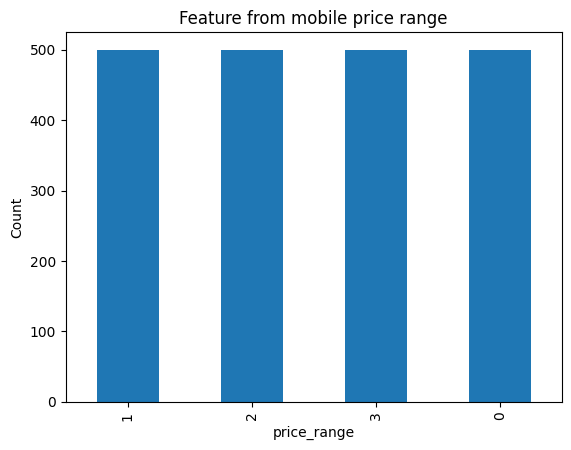

In [89]:
df["price_range"].value_counts().plot(kind="bar")
plt.title("Feature from mobile price range")
plt.xlabel("price_range")
plt.ylabel("Count")
plt.show()


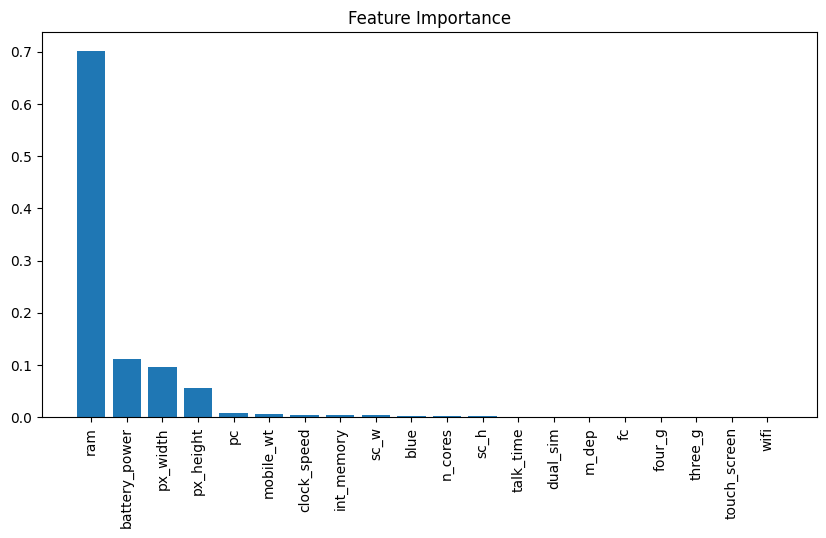

In [90]:
feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(10,5))
plt.bar(
    feature_imp["Feature"],
    feature_imp["Importance"]
)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

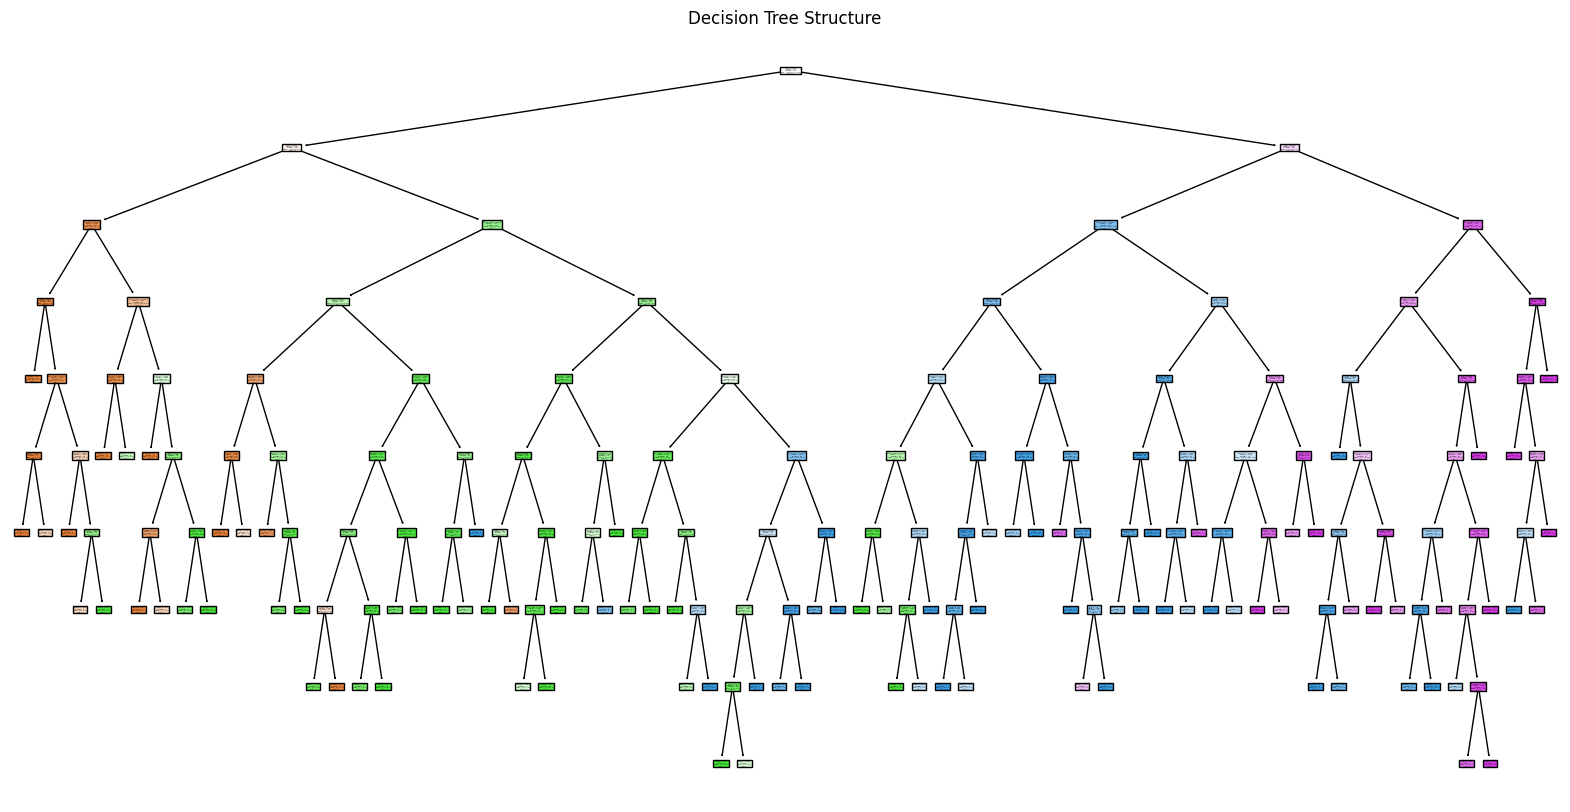

In [91]:
plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=x.columns,
    class_names=["0", "1", "2", "3"],
    filled=True
)

plt.title("Decision Tree Structure")
plt.show()